In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
iris.data.shape, iris.keys, iris.target.shape, iris.target_names, iris.feature_names

((150, 4),
 <function Bunch.keys>,
 (150,),
 array(['setosa', 'versicolor', 'virginica'], dtype='<U10'),
 ['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'])

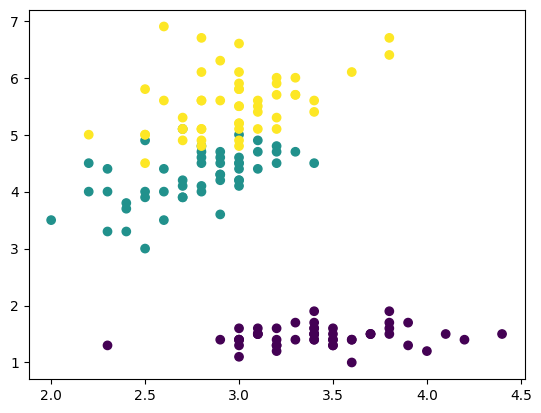

In [4]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(5,3))
plt.scatter(iris.data[:, 1], iris.data[:, 2], c=iris.target)
plt.show()

K-Nearest Neighbors Classifier

In [5]:
from sklearn import neighbors, datasets

iris=datasets.load_iris()
X,y = iris.data, iris.target

knn = neighbors.KNeighborsClassifier(n_neighbors=5, weights='uniform')

knn.fit(X,y)

X_pred = [3,5,4,2]
result=knn.predict([X_pred,])

print(iris.target_names[result])
print(iris.target_names)
print(knn.predict_proba([X_pred, ]))


['versicolor']
['setosa' 'versicolor' 'virginica']
[[0.  0.8 0.2]]


linear reg

In [6]:
from sklearn.linear_model import LinearRegression

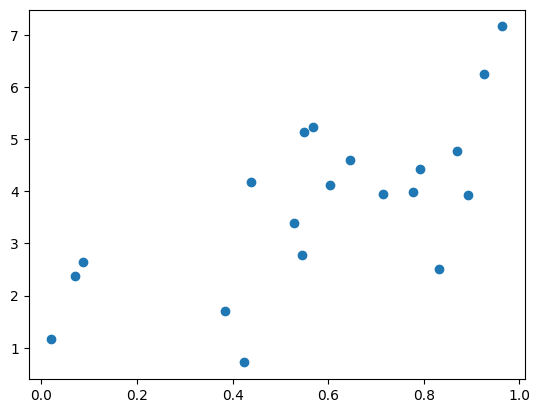

In [7]:
import numpy as np

np.random.seed(0)
X= np.random.random(size=(20,1))
y=3*X.squeeze()+2+np.random.randn(20)
plt.plot(X.squeeze(),y,'o')
plt.show()

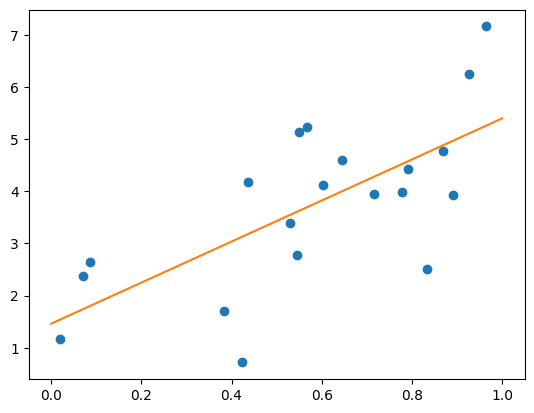

In [8]:
model=LinearRegression()
model.fit(X,y)

X_fit = np.linspace(0,1,100)[:, np.newaxis]
y_fit = model.predict(X_fit)

plt.plot(X.squeeze(), y, 'o')
plt.plot(X_fit.squeeze(), y_fit)
plt.show()

SVM

(-1.0, 3.5)

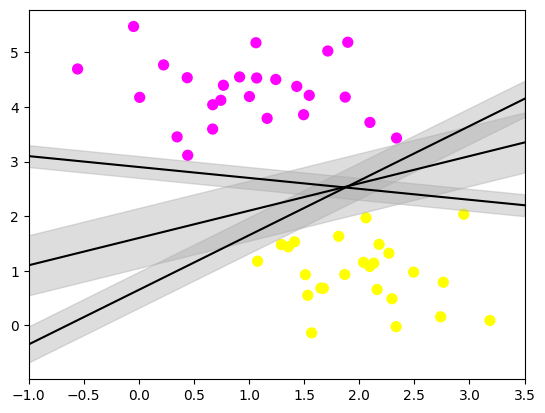

In [9]:
from sklearn.datasets._samples_generator import make_blobs
X,y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.6)

xfit=np.linspace(-1,3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='spring')

for m,b,d in [(1,0.65,0.33), (0.5,1.6,0.55), (-0.2,2.9,0.2)]:
  yfit=m*xfit+b
  plt.plot(xfit, yfit, '-k')
  plt.fill_between(xfit, yfit-d, yfit+d, edgecolor='none', color="#AAAAAA", alpha=0.4)
plt.xlim(-1,3.5)

In [10]:
from sklearn.svm import SVC
clf = SVC(kernel='linear')
clf.fit(X,y)

SVC(kernel='linear')

Kernels Classifier

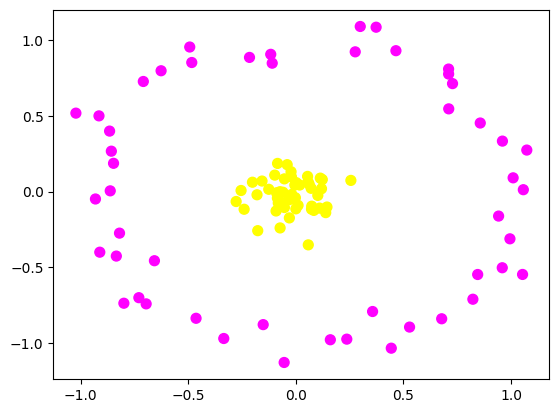

In [11]:
from sklearn.datasets._samples_generator import make_circles
X,y = make_circles(100, factor=.1, noise=.1)
clf= SVC(kernel='linear').fit(X,y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='spring')

Random Forest

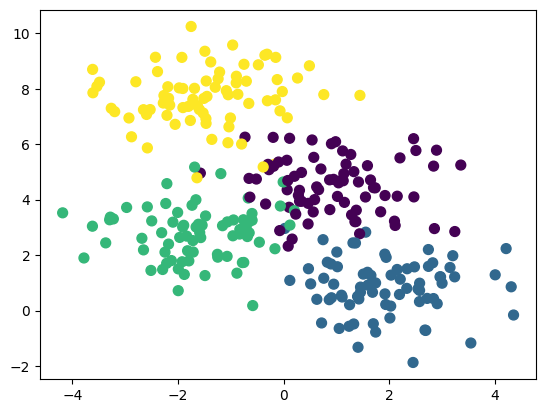

In [12]:
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')

In [13]:
from sklearn.datasets import load_iris
data = load_iris()
X,y = data.data, data.target

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_stzd = scaler.transform(X_train)
X_test_stzd = scaler.transform(X_test)

In [16]:
from sklearn.preprocessing import Normalizer
scaler=Normalizer().fit(X_train)
X_train_nrlzd = scaler.transform(X_train)
X_test_nrlzd = scaler.transform(X_test)

In [17]:
from sklearn.preprocessing import Binarizer
binarizer = Binarizer(threshold=1.0).fit(X)
X_bnrzd = binarizer.transform(X)

In [18]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [19]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [20]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)

In [21]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)
y_pred= model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R²:", r2)

MSE: 0.03711379440797686
R²: 0.9468960016420045


In [22]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [24]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [25]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train)
y_pred = kmeans.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.36666666666666664


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00         9
           2       0.85      1.00      0.92        11

    accuracy                           0.37        30
   macro avg       0.28      0.33      0.31        30
weighted avg       0.31      0.37      0.34        30



In [28]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[ 0 10  0]
 [ 7  0  2]
 [ 0  0 11]]


In [32]:
from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 0.6333333333333333


In [33]:
from sklearn.metrics import mean_squared_error
print("mse : ", mean_squared_error(y_test, y_pred))

mse :  0.6333333333333333


In [34]:
from sklearn.metrics import r2_score
print("R2 : ", r2_score(y_test, y_pred))

R2 :  0.09379968203497613


In [35]:
from sklearn.metrics import adjusted_rand_score
print("ari :", adjusted_rand_score(y_test, y_pred))

ari : 0.8104850421144351


In [37]:
from sklearn.metrics import homogeneity_score
print("homogenity : ", homogeneity_score(y_test, y_pred))

homogenity :  0.8301428848702208


In [38]:
from sklearn.metrics import completeness_score
print("completeness : ", completeness_score(y_test, y_pred))

completeness :  0.8512263588841666


In [39]:
from sklearn.metrics import v_measure_score
print("v_measure : ", v_measure_score(y_test, y_pred))

v_measure :  0.8405524341147055


# **optimizing models**

In [40]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1,1,10], 'kernel':['linear', 'rbf']}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best parameters: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Best parameters:  {'C': 1, 'kernel': 'linear'}
Best score:  0.9583333333333334


In [41]:
from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(SVC(), param_distributions={
    'C':[0.1,1,10], 'kernel':['linear', 'rbf']
}, n_iter=10)
random.fit(X_train, y_train)
print("Best parameters: ", random.best_params_)
print("Best score: ", random.best_score_)

Best parameters:  {'kernel': 'linear', 'C': 1}
Best score:  0.9583333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


# **PYTHON**

Dates and Times

In [42]:
from datetime import datetime, date, time

In [45]:
year = 2015
month = 1
day = 20
hour = 7
minute = 28
second = 15
dt = datetime(year, month, day, hour, minute, second)
print(dt)
dt.hour, dt.minute, dt.second

2015-01-20 07:28:15


(7, 28, 15)

In [48]:
dt.date()

datetime.date(2015, 1, 20)

In [49]:
dt.time()

datetime.time(7, 28, 15)

In [53]:
dt.replace(minute=10, second=57)

datetime.datetime(2015, 1, 20, 7, 10, 57)

strftime


In [54]:
dt.strftime('%m/%d/%Y %H:%M')

'01/20/2015 07:28'

strptime

In [55]:
datetime.strptime('20260814', '%Y%m%d')

datetime.datetime(2026, 8, 14, 0, 0)

timedelta

In [59]:
dt_now=datetime.now()
dt_now

datetime.datetime(2026, 8, 14, 13, 11, 14, 650336)

In [60]:
delta=dt_now - dt
delta

datetime.timedelta(days=4224, seconds=20579, microseconds=650336)

In [61]:
dt+delta

datetime.datetime(2026, 8, 14, 13, 11, 14, 650336)

FILES

read a file

In [62]:
old_file_path = 'type_util.py'
with open(old_file_path, 'r') as old_file:
  for line in old_file:
    print(line.rstrip())

write to a file

In [63]:
new_file_path = 'hello_world.txt'
with open(new_file_path, 'w') as new_file:
  new_file.write('helo world!')

read & write UTF-8

In [65]:
import codecs
with codecs.open("hello_world_new.txt", "a", "utf-8") as new_file:
    with codecs.open("hello_world.txt", "r", "utf-8") as old_file:
        for line in old_file:
            new_file.write(line + '\n')

functions

In [66]:
strings = ['foo', 'bar', 'baz', 'f', 'fo', 'b', 'ba']
strings.sort(key=lambda x:len(list(x)))
strings

['f', 'b', 'fo', 'ba', 'foo', 'bar', 'baz']

closures

In [69]:
def make_closure(x):
    def closure():
        print('Secret value is: %s' % x)
    return closure

closure = make_closure(7)
closure()

Secret value is: 7


In [72]:
def make_watcher():
  dict_seen = {}

  def watcher(x):
    if x in dict_seen:
      return True
    else:
      dict_seen[x]=True
      return False
  return watcher

watcher = make_watcher()
vals = [5, 6, 1, 5, 1, 6, 3, 5]
[watcher(x) for x in vals]

[False, False, False, True, True, True, False, True]

*args, **kwargs

In [75]:
def foo(func, arg, *args, **kwargs):
  print('arg : %s', arg)
  print('args: %s', args)
  print('kwargs %s', kwargs)
  print('func result: %s', func(args))

foo(sum, "foo", 1,2,3,4,5)

arg : %s foo
args: %s (1, 2, 3, 4, 5)
kwargs %s {}
func result: %s 15


Currying

In [76]:
def add_numbers(x,y):
  return x+y

add_seven=lambda x: add_numbers(x,7)
add_seven(3)

10

In [77]:
from functools import partial
add_five = partial(add_numbers, 5)
add_five(2)

7

data structures

tuple


In [81]:
tup = (1,2,3)
tup

(1, 2, 3)

In [82]:
li = [1,2,3]
type(tuple(li))

tuple

In [83]:
nested_tup = ([1, 2, 3], (4, 5))
nested_tup

([1, 2, 3], (4, 5))

Although tuples are immutable, their contents can contain mutable objects.

In [84]:
nested_tup[0].append(4)
nested_tup[0]

[1, 2, 3, 4]

In [85]:
(1, 3, 2) + (4, 5, 6)

(1, 3, 2, 4, 5, 6)

In [86]:
('foo', 'bar') * 2

('foo', 'bar', 'foo', 'bar')

In [87]:
a, b = nested_tup
a, b

([1, 2, 3, 4], (4, 5))

In [88]:
(a, b, c, d), (e, f) = nested_tup
a, b, c, d, e, f

(1, 2, 3, 4, 4, 5)

In [90]:
seq = [( 1, 2, 3), (4, 5, 6), (7, 8, 9)]
for a, b, c in seq:
    print(a, b, c)

1 2 3
4 5 6
7 8 9


list

In [91]:
list1 = [1,2,3]
list1

[1, 2, 3]

In [92]:
type(list(tup))

list

In [93]:
nested_list = [(1, 2, 3), [4, 5]]
nested_list

[(1, 2, 3), [4, 5]]

In [94]:
nested_list.append(6)
nested_list

[(1, 2, 3), [4, 5], 6]

In [95]:
nested_list.insert(0, 'start')
nested_list

['start', (1, 2, 3), [4, 5], 6]

In [96]:
nested_list.pop(0)
nested_list

[(1, 2, 3), [4, 5], 6]

In [97]:
nested_list.remove((1, 2, 3))
nested_list

[[4, 5], 6]

In [98]:
6 in nested_list

True

In [99]:
[1, 3, 2] + [4, 5, 6]

[1, 3, 2, 4, 5, 6]

In [100]:
nested_list.extend([7, 8, 9])
nested_list

[[4, 5], 6, 7, 8, 9]

dict

In [101]:
dict_1 = { 'a' : 'foo', 'b' : [0, 1, 2, 3] }
dict_1

{'a': 'foo', 'b': [0, 1, 2, 3]}

In [102]:
dict_1['b']

[0, 1, 2, 3]

In [103]:
dict_1[5] = 'bar'
dict_1

{'a': 'foo', 'b': [0, 1, 2, 3], 5: 'bar'}

In [104]:
5 in dict_1

True

In [105]:
dict_2 = dict(dict_1)
del dict_2[5]
dict_2

{'a': 'foo', 'b': [0, 1, 2, 3]}

In [106]:
value = dict_2.pop('b')
print(value)
print(dict_2)

[0, 1, 2, 3]
{'a': 'foo'}


In [107]:
value = dict_1.get('z', 0)
value

0

In [108]:
print(dict_1.setdefault('b', None))
print(dict_1.setdefault('z', None))

[0, 1, 2, 3]
None


In [109]:
from collections import defaultdict

seq = ['foo', 'bar', 'baz']
first_letter = defaultdict(list)
for elem in seq:
    first_letter[elem[0]].append(elem)
first_letter

defaultdict(list, {'f': ['foo'], 'b': ['bar', 'baz']})

In [111]:
print(hash('string'))
print(hash((1, 2, (3, 4))))

6842978814336870863
3794340727080330424


In [112]:
dict_1.keys()

dict_keys(['a', 'b', 5, 'z'])

In [113]:
dict_1.values()

dict_values(['foo', [0, 1, 2, 3], 'bar', None])

In [116]:
for k,v in dict_1.items():
  print(k,v)

a foo
b [0, 1, 2, 3]
5 bar
z None


In [117]:
dict_1.update({'e' : 'elephant', 'f' : 'fish'})
dict_1

{'a': 'foo',
 'b': [0, 1, 2, 3],
 5: 'bar',
 'z': None,
 'e': 'elephant',
 'f': 'fish'}

In [118]:
mapping = dict(zip(range(7), reversed(range(7))))
mapping

{0: 6, 1: 5, 2: 4, 3: 3, 4: 2, 5: 1, 6: 0}

set

In [119]:
set_1 = set([0, 1, 2, 3, 4, 5])
set_1

{0, 1, 2, 3, 4, 5}

In [120]:
set_2 = {1, 2, 3, 5, 8, 13}
set_2

{1, 2, 3, 5, 8, 13}

In [121]:
set_1 | set_2 #union

{0, 1, 2, 3, 4, 5, 8, 13}

In [122]:
set_1 & set_2 #intersection

{1, 2, 3, 5}

In [123]:
set_1 - set_2 #difference

{0, 4}

In [126]:
set_1 ^ set_2 #Symmetric Difference O(len(set_1)):

{0, 4, 8, 13}

In [127]:
set_3 = {1, 2, 3}
set_3.issubset(set_2)

True

In [128]:
set_2.issuperset(set_3)

True

In [129]:
{1, 2, 3} == {3, 2, 1}

True

In [130]:
sorted('foo bar baz')

[' ', ' ', 'a', 'a', 'b', 'b', 'f', 'o', 'o', 'r', 'z']

enumerate

In [131]:
strings = ['foo', 'bar', 'baz']
for i, string in enumerate(strings):
    print(i, string)

0 foo
1 bar
2 baz


zip

In [133]:
seq_1 = [1, 2, 3]
seq_2 = ['foo', 'bar', 'baz']
print(zip(seq_1, seq_2))

In [134]:
seq_3 = [True, False]
zip(seq_1, seq_2, seq_3)

In [135]:
for i, (a, b) in enumerate(zip(seq_1, seq_2)):
    print('%d: %s, %s' % (i, a, b))

0: 1, foo
1: 2, bar
2: 3, baz


In [139]:
numbers = [(1, 'one'), (2, 'two'), (3, 'three')]
a, b = zip(*numbers)
a

(1, 2, 3)

In [140]:
b

('one', 'two', 'three')

List Comprehensions

In [141]:
strings = ['foo', 'bar', 'baz', 'f', 'fo', 'b', 'ba']
[x.upper() for x in strings if x[0] == 'b']

['BAR', 'BAZ', 'B', 'BA']

In [142]:
list_of_tuples = [(1, 2, 3), (4, 5, 6), (7, 8, 9)]
[x for tup in list_of_tuples for x in tup]

[1, 2, 3, 4, 5, 6, 7, 8, 9]

Dict Comprehension

In [143]:
{index : val for index, val in enumerate(strings) if val[0] == 'b'}

{1: 'bar', 2: 'baz', 5: 'b', 6: 'ba'}

Set Comprehension

In [144]:
{len(x) for x in strings if x[0] == 'b'}

{1, 2, 3}